### Downloading Dataset

In [44]:
# Downloading the dataset from the Met Museum's open access repository if not already present locally.
import os
import urllib.request

DATA_DIR = "../data"
FILE_PATH = os.path.join(DATA_DIR, "MetObjects.csv")

if not os.path.exists(FILE_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    url = "https://media.githubusercontent.com/media/metmuseum/openaccess/master/MetObjects.csv"
    print("Downloading MetObjects.csv")
    urllib.request.urlretrieve(url, FILE_PATH)
    print(f"File saved to {FILE_PATH}")
else:
    print(f"File already exists at {FILE_PATH}")

File already exists at ../data/MetObjects.csv


In [45]:
# List all files in the dataset 
print("\n── Files in dataset ──")
path = DATA_DIR
for f in os.listdir(path):
    full = os.path.join(path, f)
    size_mb = os.path.getsize(full) / (1024 ** 2)
    print(f"  {f}  ({size_mb:.2f} MB)")


── Files in dataset ──
  MetObjects.csv  (302.94 MB)


### Data Overview
Quick look at dtypes, memory footprint, and how much is missing per column.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the main CSV
csv_path = os.path.join(path, "MetObjects.csv")
df = pd.read_csv(csv_path, low_memory=False)

In [28]:
# Basic overview
print(f"\n── Shape: {df.shape[0]:,} rows × {df.shape[1]} columns ──")
print("\n── Column names ──")
print(df.columns.tolist())

print("\n── First 5 rows ──")
display(df.head())

print("\n── Data types & null counts ──")
info = pd.DataFrame({
    "dtype":    df.dtypes,
    "nulls":    df.isna().sum(),
    "null_%":   (df.isna().mean() * 100).round(1),
    
})

print("\nTotal number of columns = "+ str(len(info)))

# Arrange nulls by descending order
info = info.sort_values(by='nulls', ascending=False)

display(info)


── Shape: 484,956 rows × 54 columns ──

── Column names ──
['Object Number', 'Is Highlight', 'Is Timeline Work', 'Is Public Domain', 'Object ID', 'Gallery Number', 'Department', 'AccessionYear', 'Object Name', 'Title', 'Culture', 'Period', 'Dynasty', 'Reign', 'Portfolio', 'Constituent ID', 'Artist Role', 'Artist Prefix', 'Artist Display Name', 'Artist Display Bio', 'Artist Suffix', 'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date', 'Artist End Date', 'Artist Gender', 'Artist ULAN URL', 'Artist Wikidata URL', 'Object Date', 'Object Begin Date', 'Object End Date', 'Medium', 'Dimensions', 'Credit Line', 'Geography Type', 'City', 'State', 'County', 'Country', 'Region', 'Subregion', 'Locale', 'Locus', 'Excavation', 'River', 'Classification', 'Rights and Reproduction', 'Link Resource', 'Object Wikidata URL', 'Metadata Date', 'Repository', 'Tags', 'Tags AAT URL', 'Tags Wikidata URL']

── First 5 rows ──


,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN



── Data types & null counts ──

Total number of columns = 54


,dtype,nulls,null_%
Metadata Date,float64,484956,100.0
River,str,482864,99.6
State,str,482335,99.5
Locus,str,477438,98.4
County,str,476397,98.2
Reign,str,473720,97.7
Locale,str,469217,96.8
Excavation,str,468385,96.6
Subregion,str,462813,95.4
Dynasty,str,461755,95.2


### Missing Data
A lot of columns here are >75% null

In [29]:
# Data types
print(df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
missing_df = missing_df.sort_values("Percent", ascending=False)
missing_df[missing_df["Percent"] > 0]

str        46
bool        3
int64       3
object      1
float64     1
Name: count, dtype: int64

Memory usage: 1215.0 MB


,Missing,Percent
Metadata Date,484956,100.00
River,482864,99.57
State,482335,99.46
Locus,477438,98.45
County,476397,98.24
Reign,473720,97.68
Locale,469217,96.75
Excavation,468385,96.58
Subregion,462813,95.43
Dynasty,461755,95.22


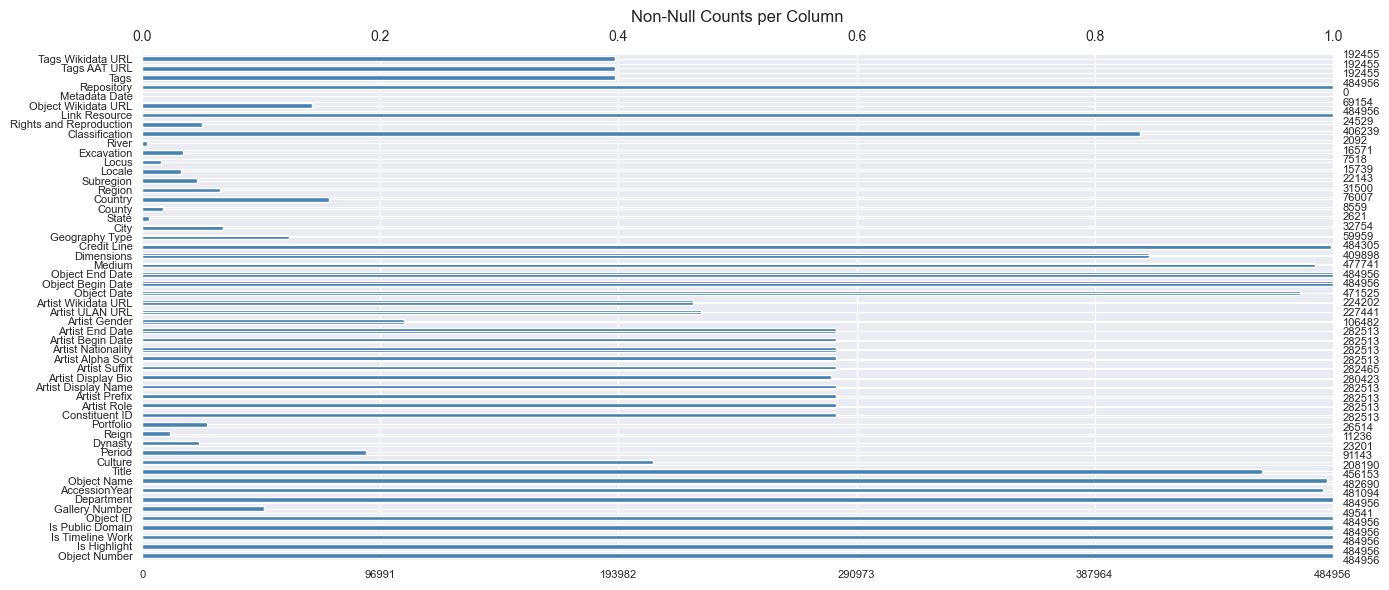

In [30]:
import missingno as msno
fig, ax = plt.subplots(figsize=(14, 6))
msno.bar(df, ax=ax, fontsize=8, color="steelblue")
plt.title("Non-Null Counts per Column")
plt.tight_layout()
# Missing data visualized
plt.show()

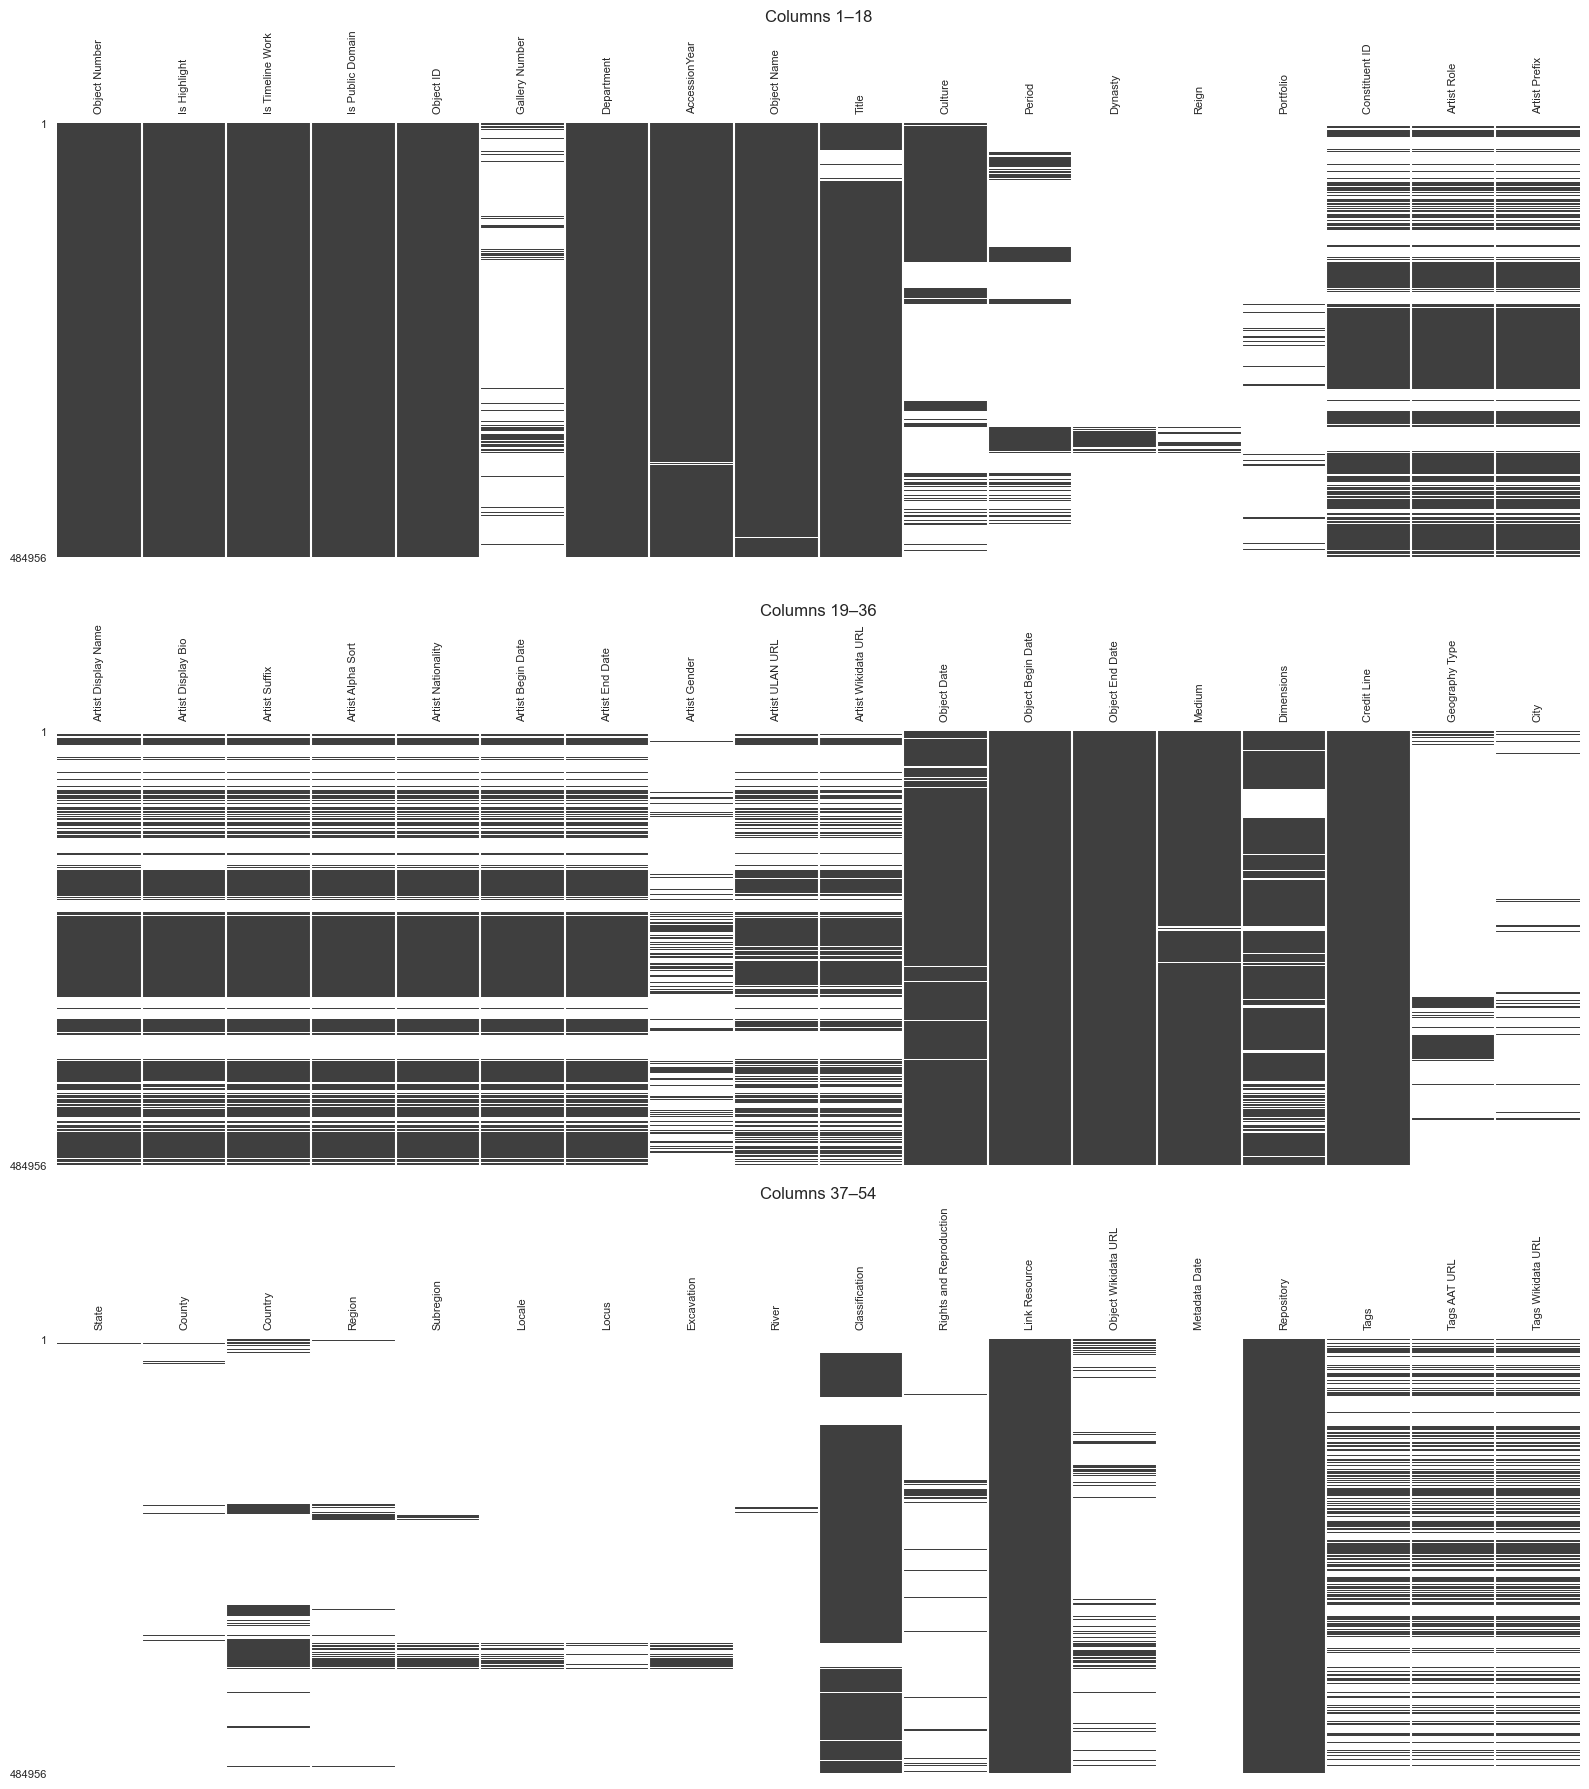

In [31]:
cols = df.columns.tolist()
third = len(cols) // 3

# splitting because the dataset has 54 columns, which is too many to visualize in one plot
splits = [cols[:third], cols[third:2*third], cols[2*third:]]
labels = ["Columns 1–18", "Columns 19–36", "Columns 37–54"]

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

for ax, subset, label in zip(axes, splits, labels):
    msno.matrix(df[subset], ax=ax, fontsize=7, sparkline=False)
    ax.set_xticks(range(len(subset)))
    # setting x-labels for mapping
    ax.set_xticklabels(subset, rotation=90, ha="center", fontsize=8)
    ax.set_title(label)

plt.tight_layout()
plt.show()

#### Observations
- Core identifiers (Object Number, Object ID, Department, AccessionYear) are fully populated — no imputation needed for these.
- Period, Dynasty, Reign, and Portfolio are mostly empty — these only apply to specific object types (e.g., Egyptian, Chinese art).
- Artist fields (Name, Bio, Nationality, Begin/End Date) go missing together — if one is absent, they all tend to be.
- Geography columns (State, County, Country, Region, Subregion, Locale, Locus) show the same block pattern — present only for excavated or site-specific objects.
- Tags and their associated URLs are partially filled, likely added retroactively for a subset of the collection.

### Department Distribution


Number of departments: 19



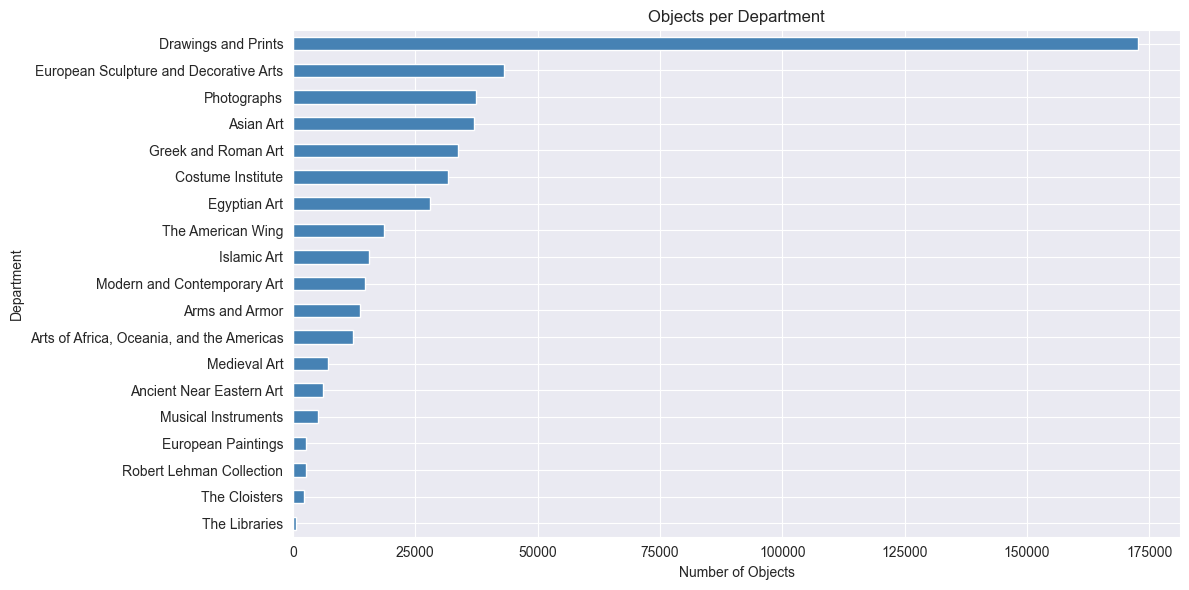

In [32]:
dept_counts = df["Department"].value_counts()
print(f"Number of departments: {dept_counts.shape[0]}\n")

fig, ax = plt.subplots(figsize=(12, 6))
dept_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of Objects")
ax.set_title("Objects per Department")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [33]:
#Key Columns - Columns we'll likely use as features
key_cols = ["Department", "Culture", "Period", "Medium", "Classification",
            "Object Name", "Object Begin Date", "Object End Date", "Tags"]

for col in key_cols:
    nunique = df[col].nunique()
    null_pct = df[col].isnull().mean() * 100
    print(f"{col:25s} | unique: {nunique:>6} | missing: {null_pct:.1f}%")

Department                | unique:     19 | missing: 0.0%
Culture                   | unique:   7313 | missing: 57.1%
Period                    | unique:   1891 | missing: 81.2%
Medium                    | unique:  65907 | missing: 1.5%
Classification            | unique:   1244 | missing: 16.2%
Object Name               | unique:  28631 | missing: 0.5%
Object Begin Date         | unique:   2076 | missing: 0.0%
Object End Date           | unique:   2041 | missing: 0.0%
Tags                      | unique:  44171 | missing: 60.3%


#### Target Class Imbalance
- Draws and Prints has 154K records while some departments have only a few hundred.
- Knowing the imbalance ratio upfront guides our choice of macro F1 over accuracy and whether resampling is needed.

In [34]:
dept_counts = df["Department"].value_counts()
dept_pct = (dept_counts / len(df) * 100).round(2)

imbalance_ratio = dept_counts.iloc[0] / dept_counts.iloc[-1]
print(f"Imbalance ratio (largest / smallest): {imbalance_ratio:.1f}x\n")

summary = pd.DataFrame({
    "Count": dept_counts,
    "Percent": dept_pct
})
display(summary)

Imbalance ratio (largest / smallest): 323.3x



,Count,Percent
Department,,
Drawings and Prints,172630,35.60
European Sculpture and Decorative Arts,43051,8.88
Photographs,37459,7.72
Asian Art,37000,7.63
Greek and Roman Art,33726,6.95
Costume Institute,31652,6.53
Egyptian Art,27969,5.77
The American Wing,18532,3.82
Islamic Art,15573,3.21


#### Object Date Distribution
- Object Begin Date spans 5000+ years of history. We check the temporal spread and flag any placeholder values (e.g. 0 or 9999) before using dates as features.


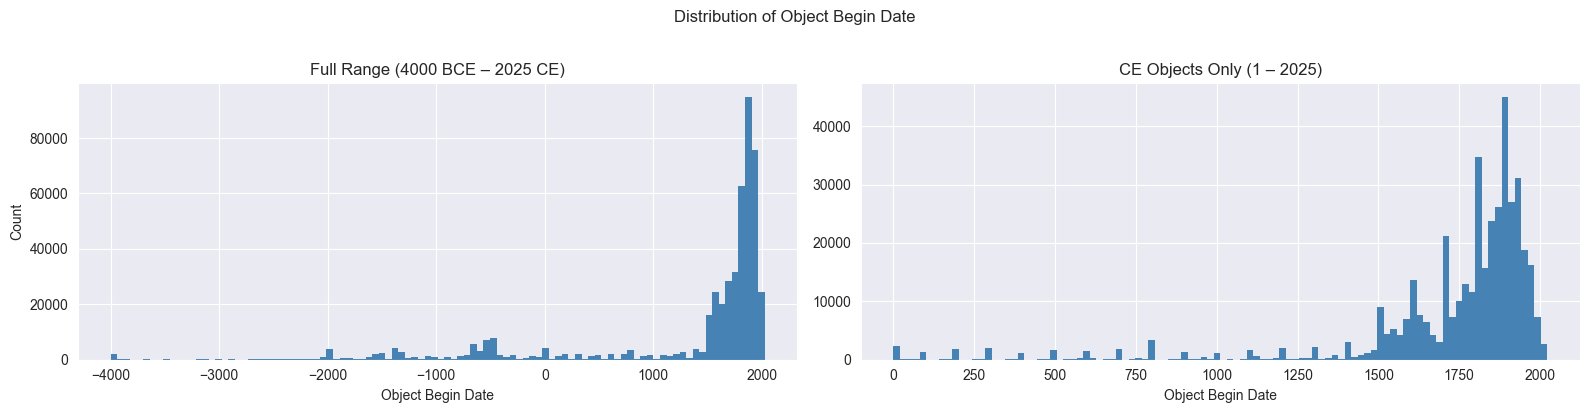

Min: -400000  |  Max: 5000
Objects before -4000: 2,074  (likely placeholder/junk values)
Objects after 2025:   2


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Full range (clipped to reasonable historical bounds)
clipped = df["Object Begin Date"].clip(lower=-4000, upper=2025)
clipped.hist(bins=100, ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_xlabel("Object Begin Date")
axes[0].set_ylabel("Count")
axes[0].set_title("Full Range (4000 BCE – 2025 CE)")

# Zoomed into CE period where most objects cluster
modern = df[df["Object Begin Date"].between(1, 2025)]["Object Begin Date"]
modern.hist(bins=100, ax=axes[1], color="steelblue", edgecolor="none")
axes[1].set_xlabel("Object Begin Date")
axes[1].set_title("CE Objects Only (1 – 2025)")

plt.suptitle("Distribution of Object Begin Date", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/object_begin_date_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Min: {df['Object Begin Date'].min()}  |  Max: {df['Object Begin Date'].max()}")
print(f"Objects before -4000: {(df['Object Begin Date'] < -4000).sum():,}  (likely placeholder/junk values)")
print(f"Objects after 2025:   {(df['Object Begin Date'] > 2025).sum():,}")

### Missingness by Department
Some columns may be systematically missing for certain departments rather than randomly missing across the board. This matters for imputation: if `Culture` is almost always null for Drawings & Prints but present for Egyptian Art, a global imputation strategy would be wrong. The heatmap below shows per-department null rates for the columns we plan to use as features.

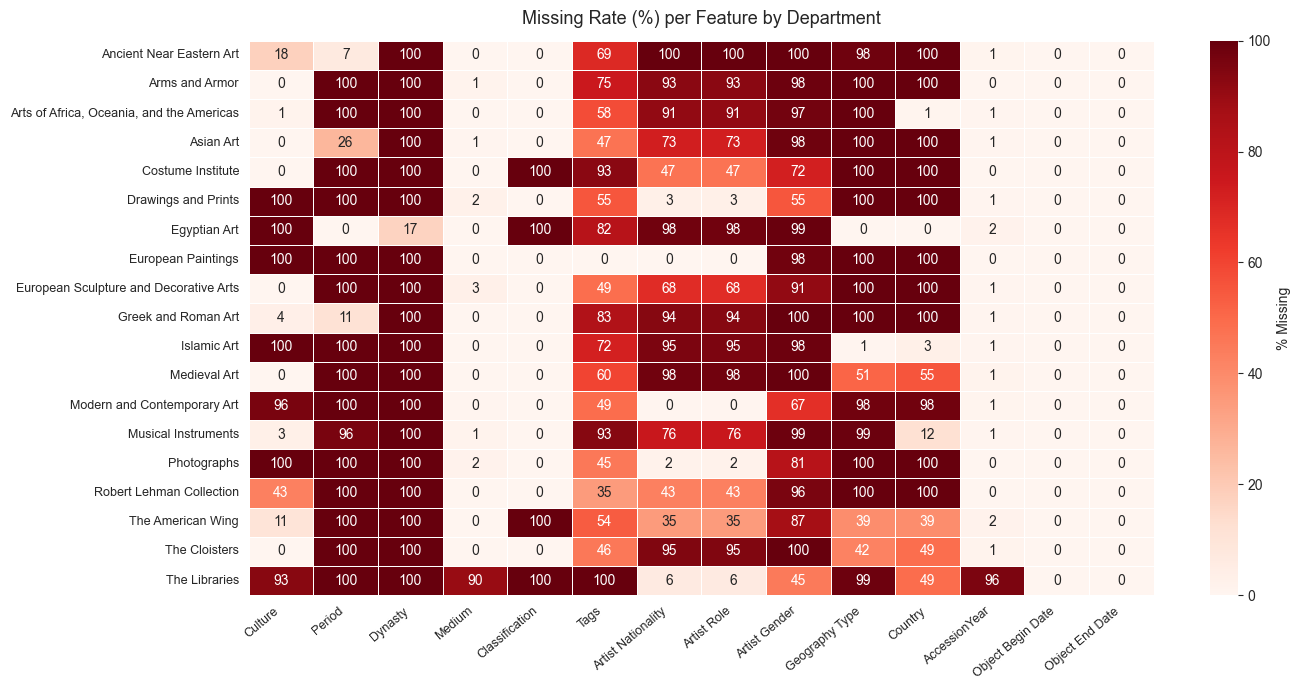

In [36]:
feature_cols = [
    'Culture', 'Period', 'Dynasty', 'Medium', 'Classification',
    'Tags', 'Artist Nationality', 'Artist Role', 'Artist Gender',
    'Geography Type', 'Country', 'AccessionYear',
    'Object Begin Date', 'Object End Date'
]

miss_by_dept = (
    df.groupby('Department')[feature_cols]
    .apply(lambda x: x.isna().mean() * 100)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    miss_by_dept,
    annot=True, fmt='.0f', cmap='Reds',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': '% Missing'},
    ax=ax
)
ax.set_title('Missing Rate (%) per Feature by Department', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/missingness_by_department.png', dpi=150)
plt.show()

### Class Imbalance
The target variable (`Department`) is heavily imbalanced. Before modeling we need to know the imbalance ratio and decide which departments to keep. Departments with very few records will cause problems during stratified train/test splits and will be nearly impossible for a classifier to learn.

In [37]:
dept_counts = df['Department'].value_counts()
imbalance_ratio = dept_counts.max() / dept_counts.min()

print(f"Departments: {len(dept_counts)}")
print(f"Imbalance ratio (largest / smallest): {imbalance_ratio:.1f}x\n")
print(dept_counts.to_string())

Departments: 19
Imbalance ratio (largest / smallest): 323.3x

Department
Drawings and Prints                          172630
European Sculpture and Decorative Arts        43051
Photographs                                   37459
Asian Art                                     37000
Greek and Roman Art                           33726
Costume Institute                             31652
Egyptian Art                                  27969
The American Wing                             18532
Islamic Art                                   15573
Modern and Contemporary Art                   14696
Arms and Armor                                13623
Arts of Africa, Oceania, and the Americas     12367
Medieval Art                                   7142
Ancient Near Eastern Art                       6223
Musical Instruments                            5227
European Paintings                             2626
Robert Lehman Collection                       2586
The Cloisters                              

In [38]:
MIN_RECORDS = 500  # departments below this are candidates for merging or dropping

small_depts = dept_counts[dept_counts < MIN_RECORDS]
keep_depts  = dept_counts[dept_counts >= MIN_RECORDS]

print(f"Departments with >= {MIN_RECORDS} records: {len(keep_depts)}")
print(f"Departments below threshold (to review): {len(small_depts)}\n")
print("--- Small departments ---")
print(small_depts.to_string())

Departments with >= 500 records: 19
Departments below threshold (to review): 0

--- Small departments ---
Series([], )


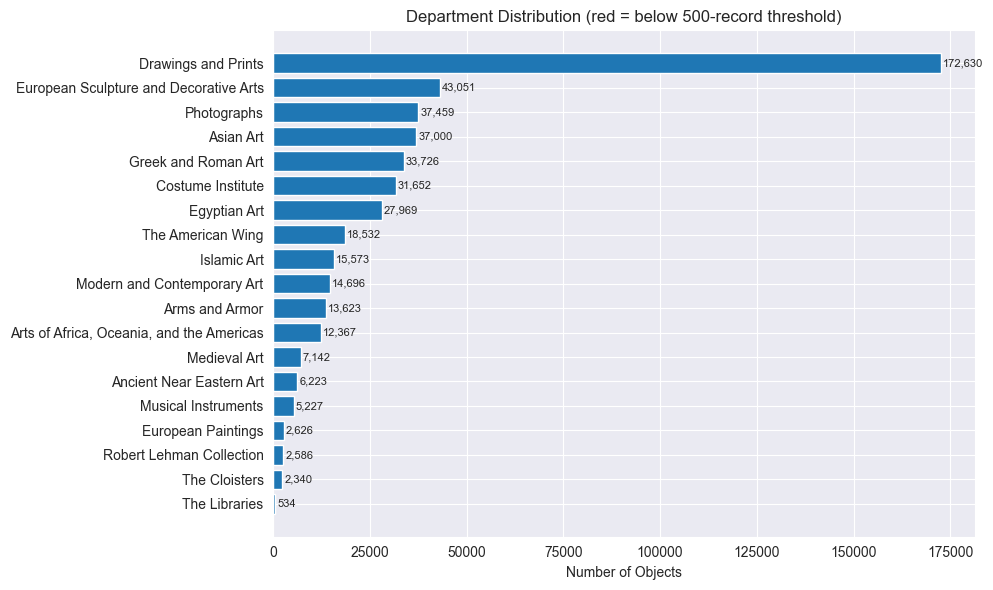

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if c < MIN_RECORDS else '#1f77b4' for c in dept_counts.values]

bars = ax.barh(dept_counts.index, dept_counts.values, color=colors)
ax.set_xlabel('Number of Objects')
ax.set_title('Department Distribution (red = below 500-record threshold)')
ax.invert_yaxis()

for bar, val in zip(bars, dept_counts.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/department_imbalance.png', dpi=150)
plt.show()

### Feature Usability Audit
A consolidated view of every column we intend to use: its non-null rate, cardinality (where relevant), and the planned encoding strategy. This is the reference point for the preprocessing pipeline.

In [40]:
audit_cols = {
    'Department':         'Target — label encode (19 classes)',
    'Medium':             'TF-IDF (free text)',
    'Classification':     'TF-IDF or top-N frequency encode',
    'Tags':               'Parse pipe-separated → TF-IDF',
    'Culture':            'Top-N frequency encode + "Other" bucket',
    'Period':             'Top-N frequency encode + "Other" bucket',
    'Dynasty':            'Top-N frequency encode + "Other" bucket',
    'Artist Nationality': 'Top-N frequency encode + "Other" bucket',
    'Artist Role':        'Low cardinality → label encode',
    'Artist Gender':      'Binary flag (Female / not)',
    'Geography Type':     'Low cardinality → label encode',
    'Country':            'Top-N frequency encode + "Other" bucket',
    'Object Begin Date':  'Numeric (keep as-is; clip outliers)',
    'Object End Date':    'Numeric (keep as-is; clip outliers)',
    'AccessionYear':      'Numeric (parse year → int)',
    'Is Highlight':       'Boolean → 0/1',
    'Is Timeline Work':   'Boolean → 0/1',
    'Is Public Domain':   'Boolean → 0/1',
}

rows = []
for col, strategy in audit_cols.items():
    if col in df.columns:
        null_pct  = df[col].isna().mean() * 100
        cardinality = df[col].nunique() if df[col].dtype == object else '—'
        rows.append({
            'Column': col,
            'Non-null %': f"{100 - null_pct:.1f}",
            'Cardinality': cardinality,
            'Planned Strategy': strategy
        })

audit_df = pd.DataFrame(rows)
display(audit_df.set_index('Column'))

,Non-null %,Cardinality,Planned Strategy
Column,,,
Department,100.0,—,Target — label encode (19 classes)
Medium,98.5,—,TF-IDF (free text)
Classification,83.8,—,TF-IDF or top-N frequency encode
Tags,39.7,—,Parse pipe-separated → TF-IDF
Culture,42.9,—,"Top-N frequency encode + ""Other"" bucket"
Period,18.8,—,"Top-N frequency encode + ""Other"" bucket"
Dynasty,4.8,—,"Top-N frequency encode + ""Other"" bucket"
Artist Nationality,58.3,—,"Top-N frequency encode + ""Other"" bucket"
Artist Role,58.3,—,Low cardinality → label encode


### High-Cardinality Categorical Coverage
`Culture` and `Artist Nationality` each have thousands of unique values. Before choosing an encoding strategy, we check how many records are covered by the top-N most frequent values — this tells us how aggressively we can bucket the long tail into an "Other" category without losing much signal.

In [41]:
def coverage_curve(series, label, top_ns=(10, 25, 50, 100, 200)):
    total_non_null = series.notna().sum()
    counts = series.value_counts()
    print(f"\n── {label} ── ({counts.shape[0]:,} unique values, {total_non_null:,} non-null records)")
    for n in top_ns:
        covered = counts.head(n).sum()
        pct = covered / total_non_null * 100
        print(f"  Top {n:>3}: {covered:>7,} records  ({pct:.1f}% of non-null)")

coverage_curve(df['Culture'], 'Culture')
coverage_curve(df['Artist Nationality'], 'Artist Nationality')
coverage_curve(df['Classification'], 'Classification')


── Culture ── (7,313 unique values, 208,190 non-null records)
  Top  10: 122,206 records  (58.7% of non-null)
  Top  25: 144,078 records  (69.2% of non-null)
  Top  50: 157,987 records  (75.9% of non-null)
  Top 100: 169,619 records  (81.5% of non-null)
  Top 200: 180,039 records  (86.5% of non-null)

── Artist Nationality ── (6,945 unique values, 282,513 non-null records)
  Top  10: 184,703 records  (65.4% of non-null)
  Top  25: 219,719 records  (77.8% of non-null)
  Top  50: 235,496 records  (83.4% of non-null)
  Top 100: 247,530 records  (87.6% of non-null)
  Top 200: 258,386 records  (91.5% of non-null)

── Classification ── (1,244 unique values, 406,239 non-null records)
  Top  10: 241,383 records  (59.4% of non-null)
  Top  25: 301,969 records  (74.3% of non-null)
  Top  50: 336,801 records  (82.9% of non-null)
  Top 100: 365,120 records  (89.9% of non-null)
  Top 200: 387,521 records  (95.4% of non-null)


### Temporal Feature Engineering Preview
`Object Begin Date` and `Object End Date` are fully populated numeric columns. We derive two engineered features here — `object_age` and `object_span` — and check whether they separate departments meaningfully. These will be direct numeric inputs to all models.

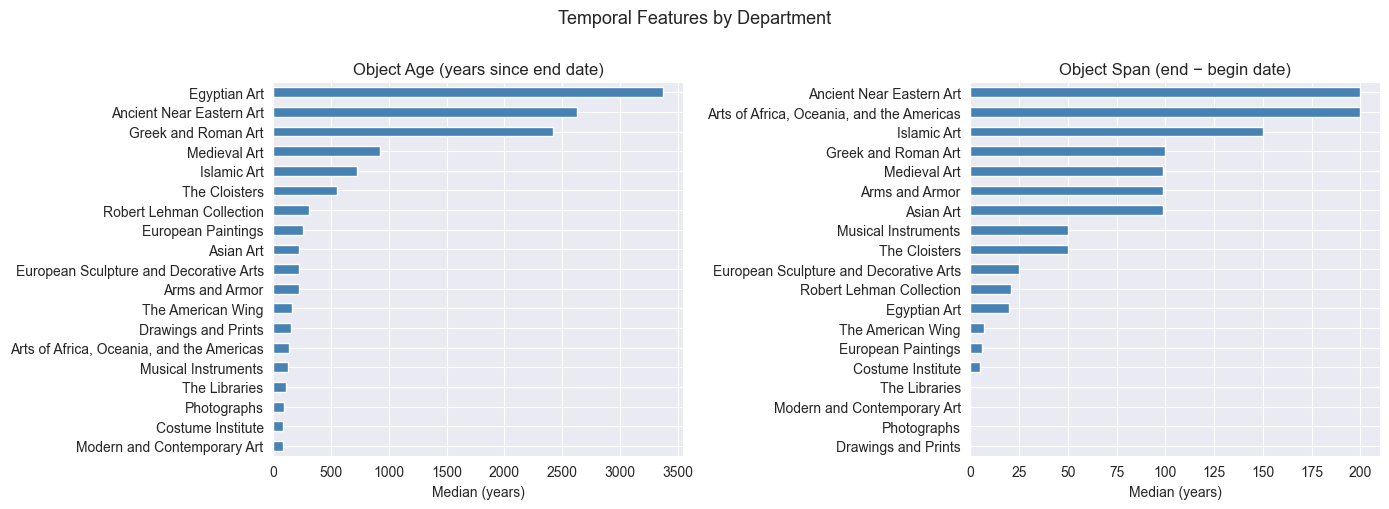


Summary stats for engineered temporal features:


,object_age,object_span
count,482882.0,482882.0
mean,610.0,69.6
std,970.1,178.8
min,-845.0,-5000.0
25%,120.0,0.0
50%,185.0,10.0
75%,426.0,98.0
max,6025.0,4900.0


Records with negative span: 205


In [42]:
CURRENT_YEAR = 2025
CLIP_MIN = -4000  # exclude likely placeholder values

temp = df[['Department', 'Object Begin Date', 'Object End Date']].copy()
temp = temp[temp['Object Begin Date'] >= CLIP_MIN]

temp['object_span'] = temp['Object End Date'] - temp['Object Begin Date']
temp['object_age']  = CURRENT_YEAR - temp['Object End Date']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_order = df['Department'].value_counts().index.tolist()

for ax, col, title in zip(
    axes,
    ['object_age', 'object_span'],
    ['Object Age (years since end date)', 'Object Span (end − begin date)']
):
    dept_medians = temp.groupby('Department')[col].median().reindex(dept_order)
    dept_medians.dropna().sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Median (years)')
    ax.set_ylabel('')

plt.suptitle('Temporal Features by Department', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/temporal_features_by_dept.png', dpi=150)
plt.show()

print("\nSummary stats for engineered temporal features:")
display(temp[['object_age', 'object_span']].describe().round(1))

print(f"Records with negative span: {(temp['object_span'] < 0).sum():,}")

### Text Feature Spot-check (Medium & Tags)
`Medium` and `Tags` will be encoded with TF-IDF. Before that, we verify they carry department-specific signal by looking at the most frequent tokens per department for `Medium`, and check average tag count per object.

In [43]:
from collections import Counter

# --- Medium: top tokens per department ---
def top_tokens(series, n=8):
    tokens = ' '.join(series.dropna().str.lower()).split(',')
    tokens = [t.strip() for t in tokens if len(t.strip()) > 2]
    return [tok for tok, _ in Counter(tokens).most_common(n)]

print("── Top Medium tokens by department ──\n")
for dept in df['Department'].value_counts().head(8).index:
    subset = df.loc[df['Department'] == dept, 'Medium']
    print(f"{dept[:40]:<42} {top_tokens(subset)}")

# --- Tags: average tag count per object ---
print("\n── Tags per object (where Tags is not null) ──")
tag_counts = df['Tags'].dropna().str.split('|').str.len()
print(tag_counts.describe().round(2))
print(f"\nObjects with at least one tag: {tag_counts.shape[0]:,}  ({tag_counts.shape[0]/len(df)*100:.1f}% of dataset)")

── Top Medium tokens by department ──

Drawings and Prints                        ['brush and brown wash', 'watercolor', 'watercolor and gouache with gum arabic pen and black ink', 'brush and gray wash', 'gouache', 'watercolor and gouache pen and black ink', 'pen and black ink', 'graphite']
European Sculpture and Decorative Arts     ['enamel', 'ivory', 'struck gilt bronze', 'mother-of-pearl', 'enamel gold', 'metal thread silk', 'silver', 'silk']
Photographs                                ['sound', 'black-and-white', 'color', 'transferred from sony av 3600 1/2-inch video tape', '1 min.', 'transferred from sony cv 1/2-inch video tape', 'transferred from panasonic 1/2-inch video tape', 'transferred from sony minidv video tape']
Asian Art                                  ['metallic thread silk', 'color', 'opaque watercolor', 'gold', 'and gold on paper ink', 'silk paper', 'roiro', 'silver']
Greek and Roman Art                        ['glazed clay', 'glass paste gold', 'white marble', 'bronz